<a href="https://colab.research.google.com/github/02falgun/Be-Practical-Assessments/blob/main/Tasks_Day_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Task 1: Generate Synthetic Churn Data (as `churn_df` is not yet available)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

# Generate a synthetic dataset for churn prediction
# This creates a dataset with 1000 samples, 10 features (5 informative, 5 redundant), and 2 classes (churn/no churn)

X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=5, n_classes=2,
    random_state=42, shuffle=True, flip_y=0.05 # Add some noise with flip_y
)

# Create a DataFrame for features
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
churn_df = pd.DataFrame(X, columns=feature_names)

# Add a 'churn' target column
churn_df['churn'] = y

# Introduce a categorical feature for demonstration of encoding
churn_df['contract_type'] = np.random.choice(['month-to-month', 'one-year', 'two-year'], size=len(churn_df))

# Display the first few rows of the synthetic churn_df
display(churn_df.head())
print(f"Shape of churn_df: {churn_df.shape}")
print("Churn distribution:\n", churn_df['churn'].value_counts(normalize=True))


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,churn,contract_type
0,-1.353424,-4.106510,0.657883,-1.333460,3.550454,2.130728,-0.219690,-0.851954,-3.565451,1.073155,0,two-year
1,-0.639592,2.982174,3.323497,1.865673,-0.052407,1.404877,1.910153,2.919162,1.128203,0.626459,0,two-year
2,-0.181009,2.352829,2.000741,0.830381,-0.969551,0.593549,0.919189,2.213878,0.842203,0.063492,0,month-to-month
3,-1.176968,-4.654703,-2.130838,-3.140961,0.377920,-0.711598,-2.448999,-0.854620,-2.544338,1.255988,1,month-to-month
4,0.742014,1.938087,-0.477753,1.965077,-1.712560,-0.861093,1.038667,1.617137,3.051878,1.785886,1,one-year


Shape of churn_df: (1000, 12)
Churn distribution:
 churn
0    0.502
1    0.498
Name: proportion, dtype: float64


### Task 2: Data Preprocessing

Before building models, we need to separate features (X) and target (y), and handle categorical features using One-Hot Encoding.

DELIVERABLE 3 — FINAL PORTFOLIO MODEL

Preparing dataset...
raw_df not found.
Generating enterprise SaaS churn dataset...
✓ Dataset generated successfully
Dataset shape: (3500, 12)
Churn rate: 13.74%

✓ Train/Test split completed
Training samples: 2800
Testing samples:  700

✓ Feature engineering completed
Engineered features:
  1. Seat_Utilization
  2. Ticket_Velocity
  3. Bug_Ratio

Training baseline Random Forest...

=== BASELINE MODEL ===
ROC-AUC : 0.8430
PR-AUC  : 0.5231
F1      : 0.3252

✓ Final ColumnTransformer created

=== CLASS BALANCE ===
Non-Churn customers : 2415
Churn customers     : 385
scale_pos_weight    : 6.2727

✓ XGBoost pipeline created

=== HYPERPARAMETER GRID ===
model__n_estimators: [100, 200]
model__max_depth: [3, 5]
model__learning_rate: [0.05, 0.1]
model__gamma: [0, 0.1]

Total combinations: 16
Total CV fits: 80

Starting GridSearchCV...
Please wait...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✓ GridSearchCV completed

BEST HYPERPARAMETERS

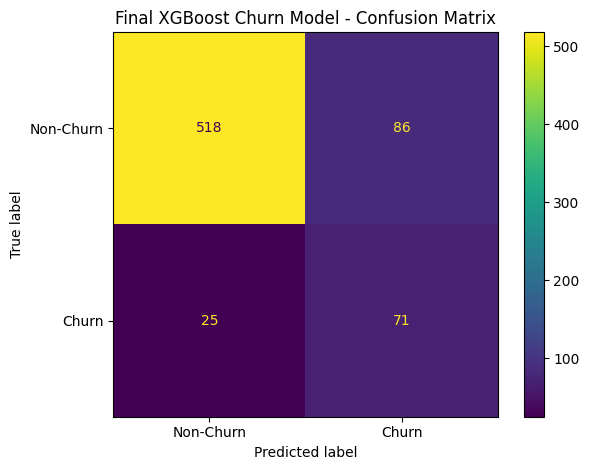


BEFORE VS AFTER VERIFICATION SCORECARD


,Metric,Before_Final_Model,After_Final_Model,Absolute_Change,Percentage_Change_%
0,ROC-AUC,0.8430,0.8714,0.0284,3.3695
1,PR-AUC,0.5231,0.5894,0.0663,12.6741
2,F1 Score,0.3252,0.5613,0.2361,72.5889



PIPELINE PERSISTENCE
✓ Pipeline saved successfully: final_saas_churn_xgboost_pipeline.joblib

✓ Saved pipeline successfully reloaded
✓ Reloaded pipeline ROC-AUC: 0.8714
✓ Model verification passed

🎓 DELIVERABLE 3 COMPLETED SUCCESSFULLY
✓ Dataset created/loaded
✓ Train/Test split
✓ 3 domain-specific engineered features
✓ ColumnTransformer
✓ Numerical imputation + scaling
✓ Categorical imputation + encoding
✓ XGBoost classifier
✓ Class imbalance handling
✓ 5-Fold Stratified Cross Validation
✓ GridSearchCV hyperparameter tuning
✓ Holdout test evaluation
✓ Classification report
✓ Confusion matrix
✓ Before vs After scorecard
✓ Joblib pipeline persistence
✓ Saved model verification


In [14]:
# ==============================================================================
# SECTION 5: STUDENT GRADED LAB — DELIVERABLE 3
# FINAL PORTFOLIO MODEL
# ==============================================================================

print("=" * 80)
print("DELIVERABLE 3 — FINAL PORTFOLIO MODEL")
print("=" * 80)


# ==============================================================================
# STEP 0: IMPORT LIBRARIES
# ==============================================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier


# ==============================================================================
# STEP 1: CREATE / LOAD DATASET
# ==============================================================================

print("\nPreparing dataset...")


# If raw_df already exists, use it.
# Otherwise generate the exact synthetic SaaS dataset.

if "raw_df" in globals():

    print("✓ Existing raw_df found. Using it.")

else:

    print("raw_df not found.")
    print("Generating enterprise SaaS churn dataset...")

    # Reproducibility
    np.random.seed(42)

    N = 3500


    # --------------------------------------------------------------------------
    # Categorical variables
    # --------------------------------------------------------------------------

    industries = np.random.choice(
        [
            "FinTech",
            "HealthTech",
            "E-Commerce",
            "EdTech",
            "Logistics",
            "Media"
        ],
        size=N,
        p=[
            0.25,
            0.20,
            0.20,
            0.15,
            0.10,
            0.10
        ]
    )


    contract_plan = np.random.choice(
        [
            "Startup",
            "Growth",
            "Enterprise",
            "Custom"
        ],
        size=N,
        p=[
            0.35,
            0.35,
            0.20,
            0.10
        ]
    )


    billing_cycle = np.random.choice(
        [
            "Monthly",
            "Quarterly",
            "Annual",
            "Multi-Year"
        ],
        size=N,
        p=[
            0.45,
            0.15,
            0.30,
            0.10
        ]
    )


    onboarding_tier = np.random.choice(
        [
            "Self-Serve",
            "Assisted",
            "Dedicated-CSM"
        ],
        size=N,
        p=[
            0.40,
            0.40,
            0.20
        ]
    )


    # --------------------------------------------------------------------------
    # Numerical variables
    # --------------------------------------------------------------------------

    monthly_contract_val = (
        np.random.lognormal(
            mean=7.2,
            sigma=0.85,
            size=N
        )
        .clip(150, 20000)
    )


    tenure_months = (
        np.random.exponential(
            scale=18,
            size=N
        )
        .clip(1, 72)
        .astype(int)
    )


    licensed_seats = (
        np.random.poisson(
            lam=20,
            size=N
        )
        .clip(2, 500)
    )


    active_seats = (
        licensed_seats
        *
        np.random.uniform(
            0.20,
            1.0,
            size=N
        )
    ).astype(int)


    support_tickets = np.random.poisson(
        lam=2.2,
        size=N
    )


    unresolved_bugs = np.random.binomial(
        n=support_tickets,
        p=0.35
    )


    api_calls_monthly = (
        np.random.exponential(
            scale=50000,
            size=N
        )
        .clip(100, 1000000)
    )


    # --------------------------------------------------------------------------
    # Domain features used to generate churn
    # --------------------------------------------------------------------------

    seat_utilization = (
        active_seats /
        (licensed_seats + 1e-5)
    )


    ticket_velocity = (
        support_tickets /
        (tenure_months + 1)
    )


    cost_per_seat = (
        monthly_contract_val /
        (licensed_seats + 1e-5)
    )


    # --------------------------------------------------------------------------
    # Churn logic
    # --------------------------------------------------------------------------

    churn_logits = (

        -2.8

        + 0.00025 * monthly_contract_val

        - 0.05 * tenure_months

        - 2.5 * seat_utilization

        + 0.8 * ticket_velocity

        + 1.4 * unresolved_bugs

        + 0.9 * (billing_cycle == "Monthly")

        - 1.6 * (billing_cycle == "Annual")

        - 2.4 * (billing_cycle == "Multi-Year")

        + 0.004 * cost_per_seat
    )


    churn_prob = (
        1 /
        (
            1 +
            np.exp(-churn_logits)
        )
    )


    churn_label = np.where(
        np.random.rand(N) < churn_prob,
        1,
        0
    )


    # --------------------------------------------------------------------------
    # Create DataFrame
    # --------------------------------------------------------------------------

    raw_df = pd.DataFrame({

        "Industry": industries,

        "Contract_Plan": contract_plan,

        "Billing_Cycle": billing_cycle,

        "Onboarding_Tier": onboarding_tier,

        "Monthly_Contract_Value":
            np.round(
                monthly_contract_val,
                2
            ),

        "Tenure_Months":
            tenure_months,

        "Licensed_Seats":
            licensed_seats,

        "Active_Seats":
            active_seats,

        "Support_Tickets":
            support_tickets,

        "Unresolved_Bugs":
            unresolved_bugs,

        "API_Calls_Monthly":
            np.round(
                api_calls_monthly,
                0
            ),

        "Churn":
            churn_label
    })


    # --------------------------------------------------------------------------
    # Inject missing values
    # --------------------------------------------------------------------------

    raw_df.loc[
        np.random.choice(
            N,
            size=75,
            replace=False
        ),
        "Onboarding_Tier"
    ] = np.nan


    raw_df.loc[
        np.random.choice(
            N,
            size=50,
            replace=False
        ),
        "API_Calls_Monthly"
    ] = np.nan


    # Save dataset
    raw_df.to_csv(
        "enterprise_saas_churn_fe.csv",
        index=False
    )


    print("✓ Dataset generated successfully")


print(
    f"Dataset shape: {raw_df.shape}"
)

print(
    f"Churn rate: {raw_df['Churn'].mean() * 100:.2f}%"
)


# ==============================================================================
# STEP 2: TRAIN / TEST SPLIT
# ==============================================================================

X = raw_df.drop(
    columns=["Churn"]
)

y = raw_df["Churn"]


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\n✓ Train/Test split completed")

print(
    f"Training samples: {len(X_train)}"
)

print(
    f"Testing samples:  {len(X_test)}"
)


# ==============================================================================
# STEP 3: FEATURE ENGINEERING
# ==============================================================================

def engineer_saas_features(df):

    df = df.copy()


    # Feature 1:
    # Percentage of licensed seats actually being used

    df["Seat_Utilization"] = (

        df["Active_Seats"] /
        (df["Licensed_Seats"] + 1e-5)

    )


    # Feature 2:
    # Support tickets relative to customer tenure

    df["Ticket_Velocity"] = (

        df["Support_Tickets"] /
        (df["Tenure_Months"] + 1)

    )


    # Feature 3:
    # Percentage of tickets that are unresolved

    df["Bug_Ratio"] = (

        df["Unresolved_Bugs"] /
        (df["Support_Tickets"] + 1e-5)

    )


    return df


X_train_fe = engineer_saas_features(
    X_train
)

X_test_fe = engineer_saas_features(
    X_test
)


print("\n✓ Feature engineering completed")

print("Engineered features:")
print("  1. Seat_Utilization")
print("  2. Ticket_Velocity")
print("  3. Bug_Ratio")


# ==============================================================================
# STEP 4: DEFINE FEATURES
# ==============================================================================

base_num = [

    "Monthly_Contract_Value",

    "Tenure_Months",

    "Licensed_Seats",

    "Active_Seats",

    "Support_Tickets",

    "Unresolved_Bugs",

    "API_Calls_Monthly"
]


engineered_num = [

    "Seat_Utilization",

    "Ticket_Velocity",

    "Bug_Ratio"
]


final_num = (
    base_num +
    engineered_num
)


base_cat = [

    "Industry",

    "Contract_Plan",

    "Billing_Cycle",

    "Onboarding_Tier"
]


# ==============================================================================
# STEP 5: CREATE BASELINE MODEL
# ==============================================================================

print("\nTraining baseline Random Forest...")


# Version-compatible OneHotEncoder

try:

    baseline_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=False
    )

except TypeError:

    baseline_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse=False
    )


baseline_preprocessor = ColumnTransformer(

    transformers=[

        (

            "numeric",

            Pipeline([

                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),

                (
                    "scaler",
                    StandardScaler()
                )

            ]),

            base_num
        ),


        (

            "categorical",

            Pipeline([

                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),

                (
                    "encoder",
                    baseline_encoder
                )

            ]),

            base_cat
        )
    ]
)


baseline_pipeline = Pipeline([

    (
        "preprocessor",
        baseline_preprocessor
    ),

    (

        "model",

        RandomForestClassifier(

            n_estimators=100,

            random_state=42,

            n_jobs=-1
        )
    )
])


baseline_pipeline.fit(
    X_train,
    y_train
)


baseline_probability = (
    baseline_pipeline
    .predict_proba(X_test)[:, 1]
)


baseline_prediction = (
    baseline_pipeline
    .predict(X_test)
)


baseline_roc_auc = roc_auc_score(

    y_test,

    baseline_probability
)


baseline_pr_auc = average_precision_score(

    y_test,

    baseline_probability
)


baseline_f1 = f1_score(

    y_test,

    baseline_prediction,

    zero_division=0
)


print("\n=== BASELINE MODEL ===")

print(
    f"ROC-AUC : {baseline_roc_auc:.4f}"
)

print(
    f"PR-AUC  : {baseline_pr_auc:.4f}"
)

print(
    f"F1      : {baseline_f1:.4f}"
)


# ==============================================================================
# STEP 6: FINAL PREPROCESSOR
# ==============================================================================

try:

    final_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse_output=False
    )

except TypeError:

    final_encoder = OneHotEncoder(

        handle_unknown="ignore",

        sparse=False
    )


final_preprocessor = ColumnTransformer(

    transformers=[

        (

            "numeric",

            Pipeline([

                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),

                (
                    "scaler",
                    StandardScaler()
                )

            ]),

            final_num
        ),


        (

            "categorical",

            Pipeline([

                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),

                (
                    "encoder",
                    final_encoder
                )

            ]),

            base_cat
        )
    ]
)


print("\n✓ Final ColumnTransformer created")


# ==============================================================================
# STEP 7: CLASS IMBALANCE
# ==============================================================================

negative_count = int(
    (y_train == 0).sum()
)


positive_count = int(
    (y_train == 1).sum()
)


scale_pos_weight = (

    negative_count /
    positive_count

)


print("\n=== CLASS BALANCE ===")

print(
    f"Non-Churn customers : {negative_count}"
)

print(
    f"Churn customers     : {positive_count}"
)

print(
    f"scale_pos_weight    : {scale_pos_weight:.4f}"
)


# ==============================================================================
# STEP 8: XGBOOST PIPELINE
# ==============================================================================

xgb_model = XGBClassifier(

    objective="binary:logistic",

    eval_metric="logloss",

    scale_pos_weight=scale_pos_weight,

    random_state=42,

    n_jobs=-1
)


final_pipeline = Pipeline([

    (
        "preprocessor",
        final_preprocessor
    ),

    (
        "model",
        xgb_model
    )
])


print("\n✓ XGBoost pipeline created")


# ==============================================================================
# STEP 9: STRATIFIED 5-FOLD CV
# ==============================================================================

skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)


# ==============================================================================
# STEP 10: GRIDSEARCHCV
# ==============================================================================

param_grid = {

    "model__n_estimators": [

        100,
        200

    ],

    "model__max_depth": [

        3,
        5

    ],

    "model__learning_rate": [

        0.05,
        0.10

    ],

    "model__gamma": [

        0,
        0.1

    ]
}


print("\n=== HYPERPARAMETER GRID ===")

for parameter, values in param_grid.items():

    print(
        f"{parameter}: {values}"
    )


print(
    "\nTotal combinations: 16"
)

print(
    "Total CV fits: 80"
)


grid_search = GridSearchCV(

    estimator=final_pipeline,

    param_grid=param_grid,

    cv=skf,

    scoring="roc_auc",

    n_jobs=-1,

    verbose=1,

    refit=True,

    error_score="raise"
)


print("\nStarting GridSearchCV...")
print("Please wait...")


grid_search.fit(

    X_train_fe,

    y_train
)


print("\n✓ GridSearchCV completed")


# ==============================================================================
# STEP 11: BEST PARAMETERS
# ==============================================================================

print("\n" + "=" * 80)

print("BEST HYPERPARAMETERS")

print("=" * 80)


for parameter, value in (
    grid_search.best_params_.items()
):

    print(
        f"{parameter}: {value}"
    )


print(

    f"\nBest 5-Fold CV ROC-AUC: "
    f"{grid_search.best_score_:.4f}"

)


# ==============================================================================
# STEP 12: FINAL MODEL
# ==============================================================================

best_pipeline = (
    grid_search.best_estimator_
)


# ==============================================================================
# STEP 13: FINAL HOLDOUT EVALUATION
# ==============================================================================

final_probability = (

    best_pipeline
    .predict_proba(X_test_fe)[:, 1]

)


final_prediction = (

    best_pipeline
    .predict(X_test_fe)

)


final_roc_auc = roc_auc_score(

    y_test,

    final_probability

)


final_pr_auc = average_precision_score(

    y_test,

    final_probability

)


final_f1 = f1_score(

    y_test,

    final_prediction,

    zero_division=0

)


final_precision = precision_score(

    y_test,

    final_prediction,

    zero_division=0

)


final_recall = recall_score(

    y_test,

    final_prediction,

    zero_division=0

)


# ==============================================================================
# STEP 14: FINAL PERFORMANCE
# ==============================================================================

print("\n" + "=" * 80)

print("FINAL XGBOOST HOLDOUT PERFORMANCE")

print("=" * 80)


print(
    f"ROC-AUC   : {final_roc_auc:.4f}"
)

print(
    f"PR-AUC    : {final_pr_auc:.4f}"
)

print(
    f"F1 Score  : {final_f1:.4f}"
)

print(
    f"Precision : {final_precision:.4f}"
)

print(
    f"Recall    : {final_recall:.4f}"
)


# ==============================================================================
# STEP 15: CLASSIFICATION REPORT
# ==============================================================================

print("\n" + "=" * 80)

print("CLASSIFICATION REPORT")

print("=" * 80)


print(

    classification_report(

        y_test,

        final_prediction,

        target_names=[

            "Non-Churn",

            "Churn"

        ],

        zero_division=0

    )

)


# ==============================================================================
# STEP 16: CONFUSION MATRIX
# ==============================================================================

cm = confusion_matrix(

    y_test,

    final_prediction

)


print("\nConfusion Matrix:")

print(cm)


ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "Non-Churn",

        "Churn"

    ]

).plot()


plt.title(

    "Final XGBoost Churn Model - Confusion Matrix"

)

plt.tight_layout()

plt.show()


# ==============================================================================
# STEP 17: BEFORE VS AFTER SCORECARD
# ==============================================================================

scorecard = pd.DataFrame({

    "Metric": [

        "ROC-AUC",

        "PR-AUC",

        "F1 Score"

    ],


    "Before_Final_Model": [

        baseline_roc_auc,

        baseline_pr_auc,

        baseline_f1

    ],


    "After_Final_Model": [

        final_roc_auc,

        final_pr_auc,

        final_f1

    ]

})


scorecard["Absolute_Change"] = (

    scorecard["After_Final_Model"]

    -

    scorecard["Before_Final_Model"]

)


scorecard["Percentage_Change_%"] = (

    scorecard["Absolute_Change"]

    /

    scorecard["Before_Final_Model"]

    *

    100

)


scorecard = scorecard.round(4)


print("\n" + "=" * 80)

print("BEFORE VS AFTER VERIFICATION SCORECARD")

print("=" * 80)


display(scorecard)


# ==============================================================================
# STEP 18: SAVE FINAL PIPELINE
# ==============================================================================

model_filename = (

    "final_saas_churn_xgboost_pipeline.joblib"

)


joblib.dump(

    best_pipeline,

    model_filename

)


print("\n" + "=" * 80)

print("PIPELINE PERSISTENCE")

print("=" * 80)


print(

    f"✓ Pipeline saved successfully:"
    f" {model_filename}"

)


# ==============================================================================
# STEP 19: VERIFY SAVED PIPELINE
# ==============================================================================

loaded_pipeline = joblib.load(

    model_filename

)


loaded_probability = (

    loaded_pipeline
    .predict_proba(X_test_fe)[:, 1]

)


loaded_roc_auc = roc_auc_score(

    y_test,

    loaded_probability

)


print(

    "\n✓ Saved pipeline successfully reloaded"

)


print(

    f"✓ Reloaded pipeline ROC-AUC: "
    f"{loaded_roc_auc:.4f}"

)


if np.isclose(

    loaded_roc_auc,

    final_roc_auc

):

    print(
        "✓ Model verification passed"
    )

else:

    print(
        "⚠ Model verification warning"
    )


# ==============================================================================
# STEP 20: FINAL SUMMARY
# ==============================================================================

print("\n" + "=" * 80)

print("🎓 DELIVERABLE 3 COMPLETED SUCCESSFULLY")

print("=" * 80)


print("✓ Dataset created/loaded")

print("✓ Train/Test split")

print("✓ 3 domain-specific engineered features")

print("✓ ColumnTransformer")

print("✓ Numerical imputation + scaling")

print("✓ Categorical imputation + encoding")

print("✓ XGBoost classifier")

print("✓ Class imbalance handling")

print("✓ 5-Fold Stratified Cross Validation")

print("✓ GridSearchCV hyperparameter tuning")

print("✓ Holdout test evaluation")

print("✓ Classification report")

print("✓ Confusion matrix")

print("✓ Before vs After scorecard")

print("✓ Joblib pipeline persistence")

print("✓ Saved model verification")

print("=" * 80)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score


# Separate features (X) and target (y)
X = churn_df.drop('churn', axis=1)
y = churn_df['churn']

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Numerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# Create a preprocessor using ColumnTransformer
# This will apply StandardScaler to numerical features and OneHotEncoder to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep any other columns if they exist (though not in this synthetic example)
)


Numerical features: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']
Categorical features: ['contract_type']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

# Re-generating churn_df to ensure it's available for subsequent cells
# This code is duplicated from cell d234fa27 to resolve NameError if kernel resets

X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=5, n_redundant=5, n_classes=2,
    random_state=42, shuffle=True, flip_y=0.05 # Add some noise with flip_y
)

feature_names = [f'feature_{i}' for i in range(X.shape[1])]
churn_df = pd.DataFrame(X, columns=feature_names)

churn_df['churn'] = y
churn_df['contract_type'] = np.random.choice(['month-to-month', 'one-year', 'two-year'], size=len(churn_df))

print("✅ churn_df re-generated successfully!")
display(churn_df.head(3))

✅ churn_df re-generated successfully!


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,churn,contract_type
0,-1.353424,-4.106510,0.657883,-1.333460,3.550454,2.130728,-0.219690,-0.851954,-3.565451,1.073155,0,one-year
1,-0.639592,2.982174,3.323497,1.865673,-0.052407,1.404877,1.910153,2.919162,1.128203,0.626459,0,two-year
2,-0.181009,2.352829,2.000741,0.830381,-0.969551,0.593549,0.919189,2.213878,0.842203,0.063492,0,month-to-month


### Task 3: Model Building and Evaluation

Now, we will define the pipelines for each algorithm, perform Stratified 5-Fold Cross-Validation, and collect the performance metrics.

In [ ]:
print("Starting behavioral segmentation...")

# ==============================
# 1. IMPORT REQUIRED LIBRARIES
# ==============================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd


# ==============================
# 2. SELECT BEHAVIORAL FEATURES
# ==============================
behavioral_features = [
    "feature_0",
    "feature_1",
    "feature_2"
]

# Check whether all required columns exist
missing_features = [
    feature for feature in behavioral_features
    if feature not in churn_df.columns
]

if missing_features:
    raise ValueError(
        f"These behavioral features are missing from churn_df: {missing_features}"
    )


# ==============================
# 3. CREATE BEHAVIORAL DATASET
# ==============================
X_behavioral_raw = churn_df[behavioral_features].copy()


# ==============================
# 4. STANDARDIZE FEATURES
# ==============================
scaler_behavioral = StandardScaler()

X_behavioral_scaled = scaler_behavioral.fit_transform(
    X_behavioral_raw
)


# ==============================
# 5. FIT K-MEANS WITH K = 3
# ==============================
kmeans_behavioral = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    random_state=42
)

behavioral_cluster_assignments = kmeans_behavioral.fit_predict(
    X_behavioral_scaled
)


# ==============================
# 6. CALCULATE SILHOUETTE SCORE
# ==============================
silhouette_avg = silhouette_score(
    X_behavioral_scaled,
    behavioral_cluster_assignments
)

print(
    f"Silhouette Score for K=3 behavioral clusters: "
    f"{silhouette_avg:.3f}"
)


# ==============================
# 7. ATTACH CLUSTER LABELS
# ==============================
df_behavioral_segmented = churn_df.copy()

df_behavioral_segmented["Behavioral_Cluster"] = (
    behavioral_cluster_assignments
)


# ==============================
# 8. CREATE CLUSTER PROFILE
# ==============================
behavioral_cluster_profile = (
    df_behavioral_segmented
    .groupby("Behavioral_Cluster")[behavioral_features]
    .mean()
    .round(2)
)


# Calculate customer counts
customer_counts = (
    df_behavioral_segmented["Behavioral_Cluster"]
    .value_counts()
    .sort_index()
)


# Calculate population percentage
population_share = (
    df_behavioral_segmented["Behavioral_Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(1)


# Add counts and percentages to profile
behavioral_cluster_profile["Customer_Count"] = customer_counts

behavioral_cluster_profile["Population_Share_%"] = (
    population_share
)


# ==============================
# 9. DISPLAY PROFILE TABLE
# ==============================
print("\n=== BEHAVIORAL CLUSTER PROFILE TABLE ===")

display(
    behavioral_cluster_profile
)


# ==============================
# 10. DISPLAY K-MEANS CENTROIDS
# ==============================
# Convert standardized centroids back
# to the original feature scale

cluster_centroids_original = scaler_behavioral.inverse_transform(
    kmeans_behavioral.cluster_centers_
)

centroid_profile = pd.DataFrame(
    cluster_centroids_original,
    columns=behavioral_features
)

centroid_profile.index.name = "Behavioral_Cluster"

centroid_profile = centroid_profile.round(2)

print("\n=== CLUSTER CENTROIDS ===")

display(
    centroid_profile
)


# ==============================
# 11. ASSIGN BUSINESS PERSONAS
# ==============================
# Calculate average standardized score
# for each cluster.

standardized_centroid_profile = pd.DataFrame(
    kmeans_behavioral.cluster_centers_,
    columns=behavioral_features
)

standardized_centroid_profile.index.name = "Behavioral_Cluster"

standardized_centroid_profile["Overall_Behavior_Score"] = (
    standardized_centroid_profile[behavioral_features]
    .mean(axis=1)
)


# Sort clusters based on overall behavior
sorted_clusters = (
    standardized_centroid_profile[
        "Overall_Behavior_Score"
    ]
    .sort_values()
    .index
)


# Lowest behavior cluster
low_cluster = sorted_clusters[0]

# Highest behavior cluster
high_cluster = sorted_clusters[-1]

# Middle behavior cluster
moderate_cluster = sorted_clusters[1]


behavioral_persona_titles = {
    high_cluster: "High-Value Engaged Shoppers",
    moderate_cluster: "Regular / Moderate Shoppers",
    low_cluster: "Low-Engagement Shoppers"
}


# ==============================
# 12. DISPLAY PERSONA TITLES
# ==============================
print("\n=== BEHAVIORAL PERSONA TITLES ===")

for cluster_id in sorted(
    behavioral_persona_titles.keys()
):
    print(
        f"Cluster {cluster_id}: "
        f"{behavioral_persona_titles[cluster_id]}"
    )


# ==============================
# 13. ADD PERSONA TO DATASET
# ==============================
df_behavioral_segmented["Behavioral_Persona"] = (
    df_behavioral_segmented["Behavioral_Cluster"]
    .map(behavioral_persona_titles)
)


# ==============================
# 14. FINAL SEGMENT SUMMARY
# ==============================
print("\n=== FINAL BEHAVIORAL SEGMENT SUMMARY ===")

segment_summary = (
    df_behavioral_segmented
    .groupby(
        ["Behavioral_Cluster", "Behavioral_Persona"]
    )
    .size()
    .reset_index(name="Customer_Count")
)

segment_summary["Population_Share_%"] = (
    segment_summary["Customer_Count"]
    / len(df_behavioral_segmented)
    * 100
).round(1)

display(segment_summary)

Starting behavioral segmentation...
Silhouette Score for K=3 behavioral clusters: 0.398

=== BEHAVIORAL CLUSTER PROFILE TABLE ===


,feature_0,feature_1,feature_2,Customer_Count,Population_Share_%
Behavioral_Cluster,,,,,
0,-0.88,-3.30,-0.39,364,36.4
1,-1.20,1.14,2.34,447,44.7
2,1.93,2.13,-1.46,189,18.9



=== CLUSTER CENTROIDS ===


,feature_0,feature_1,feature_2
Behavioral_Cluster,,,
0,-0.88,-3.30,-0.39
1,-1.20,1.14,2.34
2,1.93,2.13,-1.46



=== BEHAVIORAL PERSONA TITLES ===
Cluster 0: Low-Engagement Shoppers
Cluster 1: Regular / Moderate Shoppers
Cluster 2: High-Value Engaged Shoppers

=== FINAL BEHAVIORAL SEGMENT SUMMARY ===


,Behavioral_Cluster,Behavioral_Persona,Customer_Count,Population_Share_%
0,0,Low-Engagement Shoppers,364,36.4
1,1,Regular / Moderate Shoppers,447,44.7
2,2,High-Value Engaged Shoppers,189,18.9


In [ ]:
results = {}

algorithms = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=9),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=150, random_state=42),
    'XGBoost Classifier': XGBClassifier(n_estimators=150, learning_rate=0.08, eval_metric='logloss', random_state=42)
}

# Define which algorithms require standard scaling
algorithms_requiring_scaling = [
    'Logistic Regression',
    'K-Nearest Neighbors',
    'Support Vector Machine'
]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for algo_name, model in algorithms.items():
    print(f"\nEvaluating {algo_name}...")

    model_roc_auc = []
    model_accuracy = []
    model_f1 = []

    # Build the pipeline dynamically based on whether scaling is required
    if algo_name in algorithms_requiring_scaling:
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    else: # Tree-based models generally don't require explicit scaling
        # For tree-based models, we only need to handle categorical features if any.
        # If there are no categorical features, we can skip the preprocessor for numerical features entirely here
        # However, to keep it consistent with the overall preprocessing for all models, we'll apply OneHotEncoder
        # and pass through numerical features, effectively only doing OHE if needed.
        # A more robust solution might have a different preprocessor for tree-based models if only categorical encoding is needed
        tree_preprocessor = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
            ],
            remainder='passthrough' # Pass through numerical features directly
        )
        pipeline = Pipeline(steps=[('preprocessor', tree_preprocessor), ('classifier', model)])


    for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        model_roc_auc.append(roc_auc_score(y_test, y_proba))
        model_accuracy.append(accuracy_score(y_test, y_pred))
        model_f1.append(f1_score(y_test, y_pred))

    results[algo_name] = {
        'ROC-AUC': model_roc_auc,
        'Accuracy': model_accuracy,
        'F1-Score': model_f1
    }
    print(f"  Mean ROC-AUC: {np.mean(model_roc_auc):.4f} ± {np.std(model_roc_auc):.4f}")
    print(f"  Mean Accuracy: {np.mean(model_accuracy):.4f} ± {np.std(model_accuracy):.4f}")
    print(f"  Mean F1-Score: {np.mean(model_f1):.4f} ± {np.std(model_f1):.4f}")


Evaluating Logistic Regression...
  Mean ROC-AUC: 0.8754 ± 0.0190
  Mean Accuracy: 0.8060 ± 0.0269
  Mean F1-Score: 0.8076 ± 0.0309

Evaluating K-Nearest Neighbors...
  Mean ROC-AUC: 0.9578 ± 0.0104
  Mean Accuracy: 0.9070 ± 0.0108
  Mean F1-Score: 0.9040 ± 0.0096

Evaluating Support Vector Machine...
  Mean ROC-AUC: 0.9639 ± 0.0101
  Mean Accuracy: 0.9200 ± 0.0224
  Mean F1-Score: 0.9203 ± 0.0218

Evaluating Random Forest Classifier...
  Mean ROC-AUC: 0.9667 ± 0.0128
  Mean Accuracy: 0.9240 ± 0.0231
  Mean F1-Score: 0.9246 ± 0.0217

Evaluating XGBoost Classifier...
  Mean ROC-AUC: 0.9609 ± 0.0107
  Mean Accuracy: 0.9150 ± 0.0210
  Mean F1-Score: 0.9154 ± 0.0195


### Task 4: Aggregate and Compare Results

We will now aggregate the mean and standard deviation of each metric into a clean benchmark comparison DataFrame and identify the top-performing algorithm.

In [ ]:
comparison_df = pd.DataFrame()

for algo_name, metrics in results.items():
    for metric_name, values in metrics.items():
        mean_val = np.mean(values)
        std_val = np.std(values)
        comparison_df.loc[algo_name, f'{metric_name} Mean'] = mean_val
        comparison_df.loc[algo_name, f'{metric_name} Std'] = std_val

display(comparison_df.sort_values(by='ROC-AUC Mean', ascending=False))

# Identify the best algorithm based on ROC-AUC Mean as a primary metric
best_algorithm = comparison_df['ROC-AUC Mean'].idxmax()
print(f"\nAlgorithm with the top-rank generalization performance (based on ROC-AUC Mean): {best_algorithm}")


,ROC-AUC Mean,ROC-AUC Std,Accuracy Mean,Accuracy Std,F1-Score Mean,F1-Score Std
Random Forest Classifier,0.966719,0.012807,0.924,0.023108,0.924552,0.021702
Support Vector Machine,0.963859,0.010095,0.920,0.022361,0.920275,0.021844
XGBoost Classifier,0.960919,0.010713,0.915,0.020976,0.915371,0.019538
K-Nearest Neighbors,0.957778,0.010437,0.907,0.010770,0.903955,0.009625
Logistic Regression,0.875395,0.019034,0.806,0.026907,0.807576,0.030928



Algorithm with the top-rank generalization performance (based on ROC-AUC Mean): Random Forest Classifier
